# Practical Assignment 2 – Python Application
## Introduction
The goal of this practical assignment is to apply data analysis and knowledge extraction techniques to biological data, with a focus on predicting the mutagenicity of chemical compounds. The task involves developing a complete pipeline in Python, including data loading, preprocessing, exploratory analysis, predictive modeling, and performance evaluation.

The dataset used corresponds to the Ames test, a widely adopted biological assay for identifying compounds with mutagenic potential. It includes a matrix of numerical molecular descriptors (features) and a binary label indicating whether each compound is mutagenic (1) or not (0).

This work provides an opportunity to apply several concepts covered throughout the semester, including multivariate analysis, supervised learning, feature selection, and data visualization.


## Dataset: Ames Mutagenicity
The dataset consists of molecular descriptors for 7,273 chemical compounds and a binary target variable indicating whether each compound is mutagenic (`1`) or not (`0`).

---

## 1. Data Loading and Preprocessing


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load features and labels
features = pd.read_csv("data_csv/ames_features.csv")
labels = pd.read_csv("data_csv/ames_outputs.csv")["Y"]

# Combine into single DataFrame
data = features.copy()
data["Label"] = labels

# Check for missing values
print(data.isnull().sum().sum())  

# Feature matrix and labels
X = data.drop(columns=["Label"])
y = data["Label"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


0


## 2. Exploratory Data Analysis python


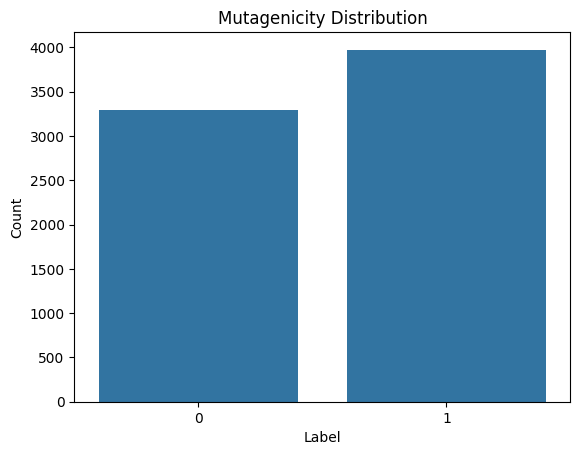

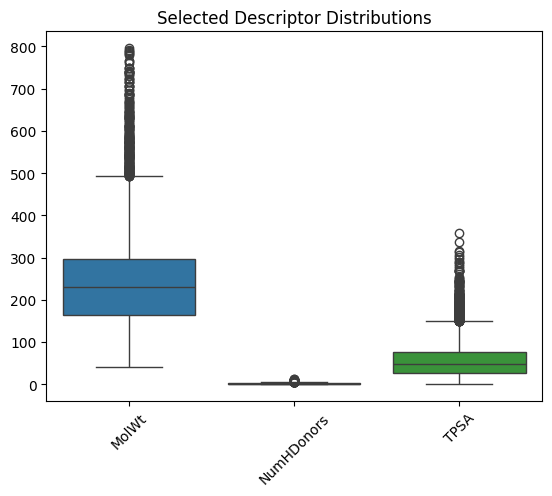

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution
sns.countplot(x=y)
plt.title("Mutagenicity Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Boxplot for selected features
sns.boxplot(data=data[["MolWt", "NumHDonors", "TPSA"]])
plt.title("Selected Descriptor Distributions")
plt.xticks(rotation=45)
plt.show()


## 3. Dimensionality Reduction (PCA) python


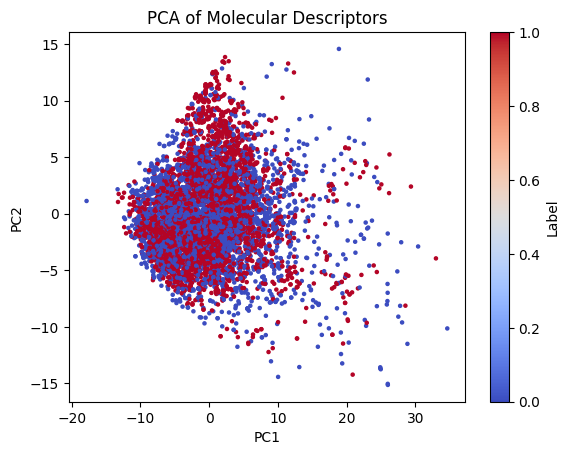

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Molecular Descriptors")
plt.colorbar(label="Label")
plt.show()


## 4. Unsupervised Analysis: Clustering

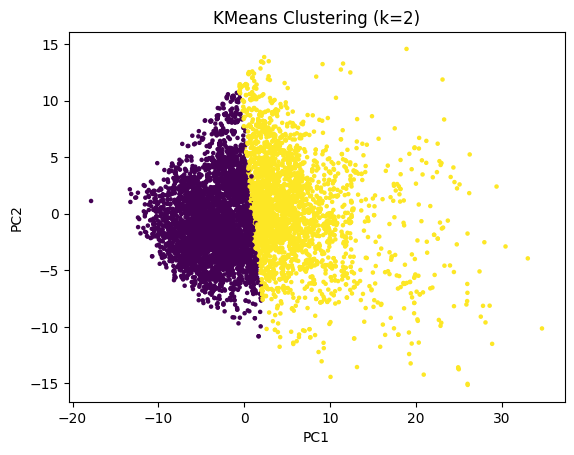

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=5)
plt.title("KMeans Clustering (k=2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## 5. Predictive Modeling: Supervised Learning

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "k-NN": KNeighborsClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probas = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, preds, output_dict=True)
    auc = roc_auc_score(y_test, probas)
    results[name] = {
        "Accuracy": report["accuracy"],
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"],
        "AUC": auc
    }

results_df = pd.DataFrame(results).T
print(results_df)


               Accuracy  Precision    Recall  F1-Score       AUC
Random Forest  0.839863   0.860677  0.839898  0.850161  0.907093
SVM            0.799313   0.817715  0.809403  0.813538  0.873987
k-NN           0.795189   0.802974  0.823380  0.813049  0.863358


## 6. Feature Importance

In [9]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
features_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(20)

print(features_importance)


                Feature  Importance
79           SlogP_VSA8    0.021322
39        HallKierAlpha    0.017885
17          BCUT2D_MWHI    0.016780
24         BCUT2D_MRLOW    0.014804
64             SMR_VSA5    0.014636
97          VSA_EState4    0.013870
1        MinEStateIndex    0.013568
23          BCUT2D_MRHI    0.013388
11     MinPartialCharge    0.013349
66             SMR_VSA7    0.013139
4                   qed    0.012948
10     MaxPartialCharge    0.012430
43               Kappa3    0.012270
12  MaxAbsPartialCharge    0.011758
13  MinAbsPartialCharge    0.011649
18         BCUT2D_MWLOW    0.011637
60            SMR_VSA10    0.011625
25             BalabanJ    0.011362
22       BCUT2D_LOGPLOW    0.011352
26              BertzCT    0.011348
